<!-- [header] -->
# September 2026 canonical forecast — seam 2026-09-02

**Status: DRAFT.** Canonical builds at the 2026-09-02 seam made 2026-09-04 with August's locked configs; not yet locked.

Plots and numeric tables only; the cycle narrative, attribution ledger and open decisions live in `_index.md`
and the spec `notes` fields.

| | |
|---|---|
| prior (N-1) | August delivered, seam 2026-08-02: desktop **48,703,443** · mobile **17,924,562** · ALL **66,628,005** |
| desktop overlays gating 2026-09-02 | `i` india_excess · `j` japan_bot · `l` launch at login for new users (200K, carried) · `o` MozillaOnline (rebuilt 2026-09-04) |
| mobile | `p` paid/organic split, measured split rebuilt for this window, GMIO paid curve |
| display layer (`adjustments/`) | `h` Win10 desktop −726,000, clamped after Dec-15 (**DRAFT**, Brad's model curve) · `u` mobile TOU −27,162 · `t` mobile tailwind +299,000 (carried) |
| targets | the low / baseline / stretch values first set in June, carried each cycle since |
| watermark | all plots DRAFT until locked (`SHOW_DRAFT_WATERMARK` in `[setup]`) |
| ladder | `[plot-desktop-ladder]` reads `adjustment_ladder/ladder_manifest.json`; rebuilt only by `scripts/build_adjustment_ladder.py`, which asks for confirmation before every model run — a rerun is a human decision, never part of a broad refresh |


In [1]:
# [setup]
import os
import subprocess
import glob
import json
import sys
import time
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from google.cloud import bigquery

os.chdir(subprocess.run(["git", "rev-parse", "--show-toplevel"], capture_output=True, text=True).stdout.strip())
sys.path.insert(0, "src")

CYCLE = "2026-09"
CYCLE_DIR = f"data-official/{CYCLE}"
PREV_CYCLE_DIR = "data-official/2026-08"

# --- Current (September) build: August's locks (desktop g01, mobile cpr 0.725) at the 2026-09-02 seam, built 2026-09-04 ---
DESKTOP_FORECAST_PATH = (
    f"{CYCLE_DIR}/desktop_g01_2026-09-02/"
    "cps0.1649_thresh032_recent17_cpr0.814_ncp40_clip0.6_sps0.00825_regimemultiplicative/"
    "mozaic_daily_forecast.2026-09-02.ld-D.adj-ijlo.parquet"
)
MOBILE_FORECAST_PATH = (
    f"{CYCLE_DIR}/mobile_cpr0725_2026-09-02/"
    "cps0.035_thresh055_recent13_cpr0.725_ncp25_clip0.6_sps0.1/"
    "mozaic_daily_forecast.2026-09-02.gm-D.adj-p.parquet"
)
DESKTOP_REQUIRED_STATE = ["i", "j", "l", "o"]
MOBILE_REQUIRED_STATE = ["p"]

# --- Prior (N-1) = August delivered (on disk, verified 2026-09-04) --------------------------------
PREV_FORECAST_DESKTOP_PATH = (
    f"{PREV_CYCLE_DIR}/desktop_g01_2026-08-02/"
    "cps0.1649_thresh032_recent17_cpr0.814_ncp40_clip0.6_sps0.00825_regimemultiplicative/"
    "mozaic_daily_forecast.2026-08-02.ld-D.adj-lo.parquet"
)
PREV_FORECAST_MOBILE_PATH = (
    f"{PREV_CYCLE_DIR}/mobile_cpr0725_2026-08-02/"
    "cps0.035_thresh055_recent13_cpr0.725_ncp25_clip0.6_sps0.1/"
    "mozaic_daily_forecast.2026-08-02.gm-D.adj-p.parquet"
)
PREV_DESKTOP_REQUIRED_STATE = ["l", "o"]
PREV_MOBILE_REQUIRED_STATE = ["p"]

# Display-layer specs: every *.json in the dir is summed, live by presence. The prior line reads
# August's own dir, so editing September's specs cannot move the comparison curve.
ADJUSTMENTS_DIR = f"{CYCLE_DIR}/adjustments"
PREV_ADJUSTMENTS_DIR = f"{PREV_CYCLE_DIR}/adjustments"
LADDER_MANIFEST = Path(f"{CYCLE_DIR}/adjustment_ladder/ladder_manifest.json")

PLOTS_DIR = f"{CYCLE_DIR}/plots"
CSV_DIR = f"{CYCLE_DIR}/csv"
os.makedirs(PLOTS_DIR, exist_ok=True)

# --- Dates ---------------------------------------------------------------------------------------
DISPLAY_START = pd.Timestamp("2026-01-01")
DISPLAY_END = pd.Timestamp("2026-12-31")
FORECAST_START = pd.Timestamp("2026-09-02")          # seam, both platforms (training through 2026-09-01)
MOBILE_FORECAST_START = FORECAST_START
PREV_FORECAST_START = pd.Timestamp("2026-08-02")     # August's seam
MEASUREMENT_DATE = pd.Timestamp("2026-12-15")
TROUGH_WINDOW_END = pd.Timestamp("2026-10-15")
BQ_START = "2025-12-04"                              # 28 days before DISPLAY_START for the trailing MA

# --- Pinned prior-cycle numbers (../2026-08/_index.md) --------------------------------------------
AUGUST_DELIVERED_DESKTOP_DEC15 = 48_703_443
AUGUST_DELIVERED_MOBILE_DEC15 = 17_924_562

# --- Dec-15 targets (set in June 2026, carried unchanged each cycle) -----------------------------
TARGETS = {
    "desktop": {"Low": 49_039_852, "Baseline": 49_513_157, "Stretch": 49_772_388},
    "mobile": {"Low": 17_019_424, "Baseline": 17_522_795, "Stretch": 17_742_615},
}
TARGETS["ALL"] = {k: TARGETS["desktop"][k] + TARGETS["mobile"][k] for k in TARGETS["desktop"]}

# Every plot is stamped DRAFT until the September forecast is LOCKED. Flip this one flag at lock time; never
# remove the watermark per chart.
SHOW_DRAFT_WATERMARK = True

_missing = [n for n, v in [("DESKTOP_FORECAST_PATH", DESKTOP_FORECAST_PATH), ("MOBILE_FORECAST_PATH", MOBILE_FORECAST_PATH)] if v is None]
if _missing:
    raise RuntimeError(f"September build not wired yet: set {_missing} in [setup].")
print(f"cwd: {os.getcwd()} | seam {FORECAST_START.date()} | prior seam {PREV_FORECAST_START.date()}")


cwd: /Users/brendanwells/work/mozaic-daily | seam 2026-09-02 | prior seam 2026-08-02


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/google/api_core/_python_version_support.py:266: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.cloud.bigquery_storage_v1 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.bigquery_storage_v1 past that date.
  warnings.warn(message, FutureWarning)


In [2]:
# [helpers]
from mozaic_daily.seam_ma import display_ma, daily_to_28ma                        # noqa: E402
from mozaic_daily.adjustments import (                                            # noqa: E402
    load_forecast, render_adjustment, load_adjustments_from_dir, apply_net_adjustment_to_series,
)


def load_all_level_dau(path, data_source, segment_filter, app_filter, *, require_state):
    """Validated load of one parquet -> World(ALL) daily DAU with data_type, plus its sidecar meta."""
    df, meta = load_forecast(path, require_state=require_state)
    mask = ((df["country"] == "ALL") & (df["segment"] == segment_filter)
            & (df["data_source"] == data_source) & (df["app_name"] == app_filter))
    result = df.loc[mask, ["target_date", "dau", "data_type"]].copy()
    result["target_date"] = pd.to_datetime(result["target_date"])
    return result.sort_values("target_date").reset_index(drop=True), meta


def millions_formatter(x, pos):
    return f"{x / 1e6:.2f}M"   # two decimals so 0.5M-spaced ticks stay distinct


def clip_display(s):
    return s[(s.index >= DISPLAY_START) & (s.index <= DISPLAY_END)].dropna()


def clip_forecast_only(s, forecast_start):
    return s[(s.index >= forecast_start) & (s.index <= DISPLAY_END)].dropna()


def draw_targets(ax, platform):
    for (label, value), marker in zip(TARGETS[platform].items(), ["^", "v", "D"]):
        ax.plot(MEASUREMENT_DATE, value, marker=marker, color="gold", markersize=12, markeredgecolor="black",
                markeredgewidth=0.8, linestyle="None", label=f"Target {label} ({value:,})")


def style_time_axis(ax, *, title, legend_loc):
    ax.set_title(title, fontsize=14)
    ax.set_ylabel("DAU")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(millions_formatter))
    ax.legend(loc=legend_loc, fontsize=9)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()


def add_draft_watermark(ax, text="DRAFT"):
    """Large diagonal DRAFT stamp; no-op once SHOW_DRAFT_WATERMARK is False (forecast locked)."""
    if not SHOW_DRAFT_WATERMARK:
        return
    ax.text(0.5, 0.5, text, transform=ax.transAxes, fontsize=120, color="#c0392b", alpha=0.16,
            ha="center", va="center", rotation=28, zorder=100, fontweight="bold", clip_on=True)


def save_and_show(fig, savename):
    """Every chart goes through here, so the watermark is applied in exactly one place."""
    for ax in fig.axes:
        add_draft_watermark(ax)
    out = f"{PLOTS_DIR}/{savename}"
    fig.savefig(out, dpi=130)
    print(f"saved: {out}")
    plt.show()


def dec15_table(title, series: dict, platform):
    """Pasteable table: each series at Dec-15, then each target with the current forecast's delta to it."""
    current = series["Current (Sep 2026)"].get(MEASUREMENT_DATE, np.nan)
    print(title)
    header = f"{'Series / target':<30s} {'Dec 15 28d-MA':>16s} {'Current − row':>16s} {'%':>8s}"
    print(header)
    print("-" * len(header))
    for name, s in series.items():
        v = s.get(MEASUREMENT_DATE, np.nan)
        print(f"{name:<30s} {v:>16,.0f} {current - v:>+16,.0f} {(current / v - 1) * 100:>+7.2f}%")
    for name, v in TARGETS[platform].items():
        print(f"{'Target ' + name:<30s} {v:>16,.0f} {current - v:>+16,.0f} {(current / v - 1) * 100:>+7.2f}%")


/Users/brendanwells/work/mozaic-daily/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
# [load-parquets]
desktop_raw, desktop_meta = load_all_level_dau(
    DESKTOP_FORECAST_PATH, "legacy_desktop", '{"os": "ALL"}', "desktop", require_state=DESKTOP_REQUIRED_STATE)
mobile_raw, mobile_meta = load_all_level_dau(
    MOBILE_FORECAST_PATH, "glean_mobile", "{}", "ALL MOBILE", require_state=MOBILE_REQUIRED_STATE)

for label, df, seam in [("Desktop", desktop_raw, FORECAST_START), ("Mobile", mobile_raw, MOBILE_FORECAST_START)]:
    last_train = df.loc[df["data_type"] == "training", "target_date"].max()
    assert last_train == seam - pd.Timedelta(days=1), f"{label}: last training {last_train.date()} != seam-1"
    print(f"{label:8s} {len(df)} rows, {df['target_date'].min().date()} to {df['target_date'].max().date()}"
          f" | seam {seam.date()} | last training {last_train.date()}")

# Locked configs. TODO: September's; seeded with August's (desktop g01, mobile cpr 0.725).
EXPECTED_DESKTOP_CONFIG = {
    "seasonality_regime": "multiplicative", "prophet_changepoint_prior_scale": 0.1649,
    "prophet_changepoint_range": 0.814, "prophet_n_changepoints": 40, "prophet_recent_weeks": 17,
    "prophet_seasonality_prior_scale": 0.00825,
}
EXPECTED_MOBILE_CONFIG = {
    "prophet_changepoint_prior_scale": 0.035, "prophet_changepoint_range": 0.725, "prophet_n_changepoints": 25,
    "prophet_recent_weeks": 13, "holiday_threshold": -0.055, "holiday_max_radius": 5, "holiday_min_radius": 3,
    "holiday_effect_floor": -0.6,
}
DESKTOP_HOLIDAY_DEFAULTS = {   # excluded from tuning by policy
    "holiday_threshold": -0.032, "holiday_max_radius": 5, "holiday_min_radius": 3, "holiday_effect_floor": -0.6,
}
for label, meta, expected in [("desktop", desktop_meta, EXPECTED_DESKTOP_CONFIG),
                              ("mobile", mobile_meta, EXPECTED_MOBILE_CONFIG),
                              ("desktop holiday knobs", desktop_meta, DESKTOP_HOLIDAY_DEFAULTS)]:
    actual = meta["model_config"]
    drift = {k: (v, actual.get(k)) for k, v in expected.items() if actual.get(k) != v}
    assert not drift, f"{label} drifted from its lock: {drift}"
    print(f"{label} matches lock ({len(expected)} params checked)")

print("\nAdjustments recorded in sidecars:")
for label, meta in [("desktop", desktop_meta), ("mobile", mobile_meta)]:
    for adj in meta.get("adjustments_applied", []):
        print(f"  {label:8s} {adj['code']}  {adj.get('name', '')}  spec={adj.get('spec_file', '')}")


Desktop  2922 rows, 2020-01-01 to 2027-12-31 | seam 2026-09-02 | last training 2026-09-01
Mobile   2557 rows, 2020-12-31 to 2027-12-31 | seam 2026-09-02 | last training 2026-09-01
desktop matches lock (6 params checked)
mobile matches lock (8 params checked)
desktop holiday knobs matches lock (4 params checked)

Adjustments recorded in sidecars:
  desktop  i  india_excess  spec=/Users/brendanwells/work/mozaic-daily/data-official/2026-09/india_excess/india_excess.json
  desktop  j  japan_bot  spec=/Users/brendanwells/work/mozaic-daily/data-official/2026-09/japan_bot/japan_bot.json
  desktop  l  launch_on_login_new_users  spec=/Users/brendanwells/work/mozaic-daily/data-official/2026-09/launch_on_login/lol.json
  desktop  o  mozillaonline_migration  spec=/Users/brendanwells/work/mozaic-daily/data-official/2026-09/mozillaonline/mozillaonline.json
  mobile   p  paid_organic_split  spec=data-official/2026-09/organic/organic.json


In [4]:
# [load-prev-forecast]
prev_desktop_raw, prev_desktop_meta = load_all_level_dau(
    PREV_FORECAST_DESKTOP_PATH, "legacy_desktop", '{"os": "ALL"}', "desktop", require_state=PREV_DESKTOP_REQUIRED_STATE)
prev_mobile_raw, prev_mobile_meta = load_all_level_dau(
    PREV_FORECAST_MOBILE_PATH, "glean_mobile", "{}", "ALL MOBILE", require_state=PREV_MOBILE_REQUIRED_STATE)
_prev_last_train = prev_desktop_raw.loc[prev_desktop_raw.data_type == "training", "target_date"].max()
assert _prev_last_train == PREV_FORECAST_START - pd.Timedelta(days=1), "PREV_FORECAST_START is wrong"
print(f"Prior desktop: {len(prev_desktop_raw)} rows | mobile: {len(prev_mobile_raw)} rows | seam {PREV_FORECAST_START.date()}")


Prior desktop: 2922 rows | mobile: 2557 rows | seam 2026-08-02


In [5]:
# [bq-actuals]
# Cutoff CURRENT_DATE("America/Los_Angeles") - 2: the newest landed Glean day can be partial, and plain
# CURRENT_DATE() is UTC.
client = bigquery.Client(project="moz-fx-data-bq-data-science")

queries = {
    "desktop": f"""
        SELECT submission_date AS date, SUM(dau) AS dau
        FROM `moz-fx-data-shared-prod.telemetry.active_users_aggregates`
        WHERE app_name = "Firefox Desktop"
          AND submission_date BETWEEN '{BQ_START}' AND CURRENT_DATE("America/Los_Angeles") - 2
        GROUP BY submission_date ORDER BY 1
    """,
    "mobile": f"""
        SELECT submission_date AS date, SUM(dau) AS dau
        FROM `moz-fx-data-shared-prod.glean_telemetry.active_users_aggregates`
        WHERE app_name IN ("Fenix", "Firefox iOS", "Focus Android", "Focus iOS")
          AND submission_date BETWEEN '{BQ_START}' AND CURRENT_DATE("America/Los_Angeles") - 2
        GROUP BY submission_date ORDER BY 1
    """,
}

bq_actuals = {}
t0 = time.time()
for i, (name, sql) in enumerate(queries.items(), 1):
    sys.stdout.write(f"[{i}/{len(queries)}] {name}...")
    sys.stdout.flush()
    df = client.query(sql).to_dataframe()
    df["date"] = pd.to_datetime(df["date"])
    bq_actuals[name] = df
    sys.stdout.write(f" {len(df)} rows, through {df['date'].max().date()} ({time.time() - t0:.1f}s)\n")
    sys.stdout.flush()


[1/2] desktop...

 273 rows, through 2026-09-02 (8.6s)


[2/2] mobile...

 273 rows, through 2026-09-02 (13.4s)


In [6]:
# [compute-series]
# Forecast curves: variance-matched display_ma (identical to rolling(28) from seam+27 on). Actuals: plain
# trailing MA. Display-layer specs are summed onto the MA from each curve's OWN seam forward.
desktop_ma_raw = display_ma(desktop_raw["target_date"], desktop_raw["dau"], FORECAST_START)
mobile_ma_raw = display_ma(mobile_raw["target_date"], mobile_raw["dau"], MOBILE_FORECAST_START)

net_adjustments = load_adjustments_from_dir(ADJUSTMENTS_DIR, desktop_ma_raw.index, require_specs=True)
prev_net_adjustments = load_adjustments_from_dir(PREV_ADJUSTMENTS_DIR, desktop_ma_raw.index, require_specs=True)

desktop_ma = apply_net_adjustment_to_series(desktop_ma_raw, net_adjustments, "desktop", FORECAST_START)
mobile_ma = apply_net_adjustment_to_series(mobile_ma_raw, net_adjustments, "mobile", MOBILE_FORECAST_START)

desktop_actual_ma = daily_to_28ma(bq_actuals["desktop"]["date"], bq_actuals["desktop"]["dau"])
mobile_actual_ma = daily_to_28ma(bq_actuals["mobile"]["date"], bq_actuals["mobile"]["dau"])

prev_desktop_ma = apply_net_adjustment_to_series(
    display_ma(prev_desktop_raw["target_date"], prev_desktop_raw["dau"], PREV_FORECAST_START),
    prev_net_adjustments, "desktop", PREV_FORECAST_START)
prev_mobile_ma = apply_net_adjustment_to_series(
    display_ma(prev_mobile_raw["target_date"], prev_mobile_raw["dau"], PREV_FORECAST_START),
    prev_net_adjustments, "mobile", PREV_FORECAST_START)

print(f"{'display layer at Dec-15':<26s} {'desktop':>12s} {'mobile':>12s}")
for label, adj in [("current (Sep)", net_adjustments), ("prior (Aug delivered)", prev_net_adjustments)]:
    print(f"{label:<26s} {adj['desktop'].get(MEASUREMENT_DATE, np.nan):>+12,.0f} {adj['mobile'].get(MEASUREMENT_DATE, np.nan):>+12,.0f}")
print("specs applied:", sorted(os.path.basename(p) for p in glob.glob(f"{ADJUSTMENTS_DIR}/*.json")))


display layer at Dec-15         desktop       mobile
current (Sep)                  -726,000     +271,838
prior (Aug delivered)        -1,315,000     +271,838
specs applied: ['headwind.json', 'tailwind.json', 'tou_mobile_headwind.json']


In [7]:
# [compute-2025-reference]
# 2025 actuals (parquet `training` rows, verified raw by scripts/verify_training_rows_are_actuals.py) as a
# 28d MA, calendar-shifted onto 2026. Levels not rebased. Feeds the *_with_2025 plots and [gap-to-flat].
REFERENCE_YEAR = 2025


def build_prior_year_reference(df, year=REFERENCE_YEAR):
    training = df.loc[df["data_type"] == "training"]
    ma = daily_to_28ma(training["target_date"], training["dau"])
    reference = ma[ma.index.year == year].dropna()   # select AFTER the MA so January has a full window
    reference.index = reference.index + pd.DateOffset(years=DISPLAY_START.year - year)
    return reference


desktop_ref_2025 = build_prior_year_reference(desktop_raw)
mobile_ref_2025 = build_prior_year_reference(mobile_raw)
for label, reference in [("desktop", desktop_ref_2025), ("mobile", mobile_ref_2025)]:
    assert reference.index.year.unique().tolist() == [DISPLAY_START.year], f"{label} reference did not shift onto {DISPLAY_START.year}"
    assert len(reference) == 365, f"{label} reference has {len(reference)} days, expected 365"
    print(f"{label:8s} {REFERENCE_YEAR} 28d-MA range {reference.min():>13,.0f} to {reference.max():>13,.0f} | Dec 15 {reference.get(MEASUREMENT_DATE):>13,.0f}")


desktop  2025 28d-MA range    47,055,549 to    53,951,746 | Dec 15    51,846,238
mobile   2025 28d-MA range    13,428,034 to    15,713,215 | Dec 15    15,690,719


saved: data-official/2026-09/plots/desktop_current_vs_august.png


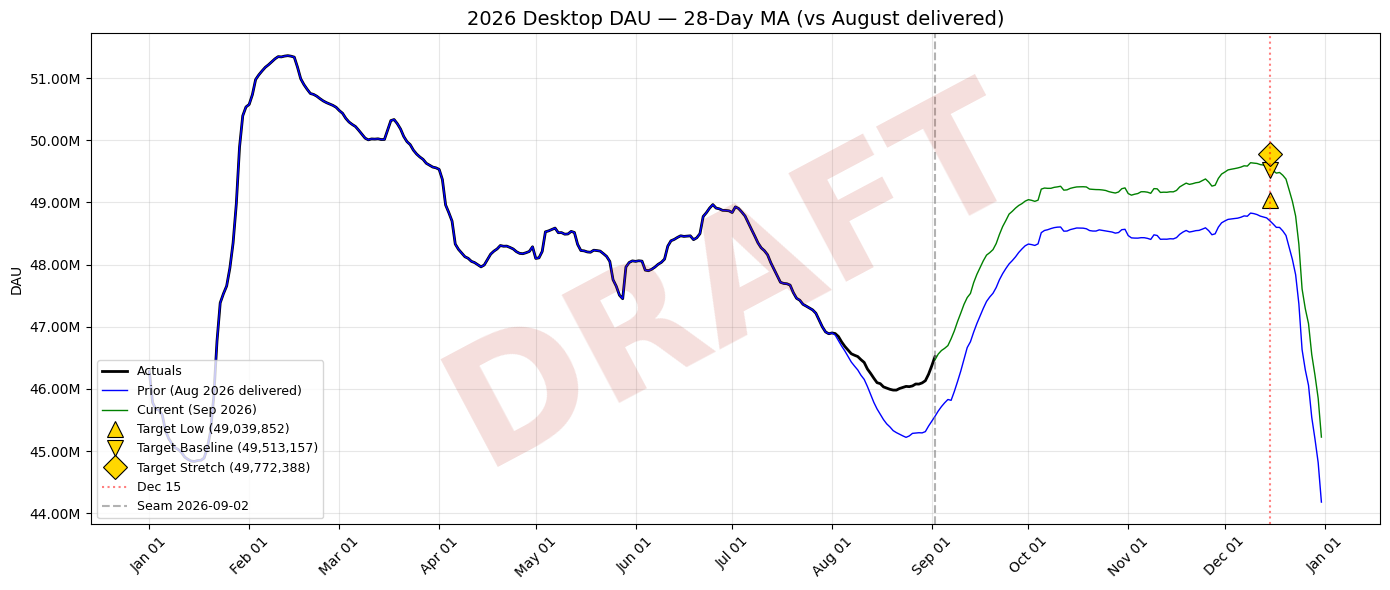

saved: data-official/2026-09/plots/desktop_current_vs_august_with_2025.png


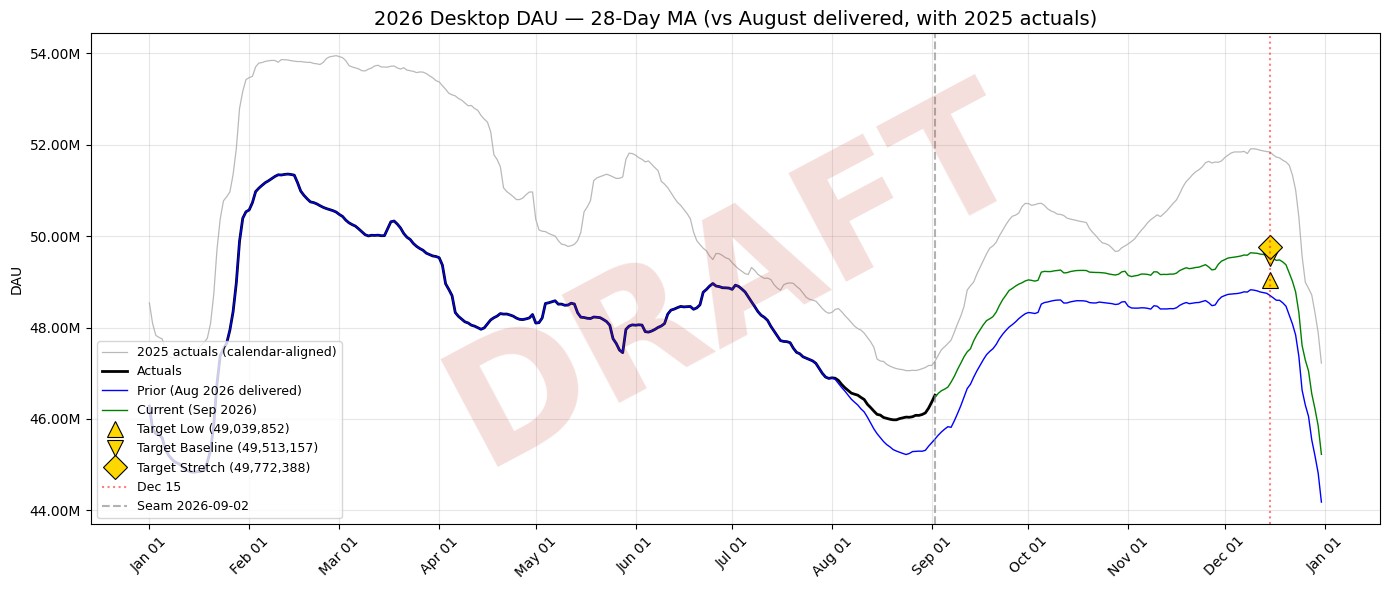

saved: data-official/2026-09/plots/desktop_current_only.png


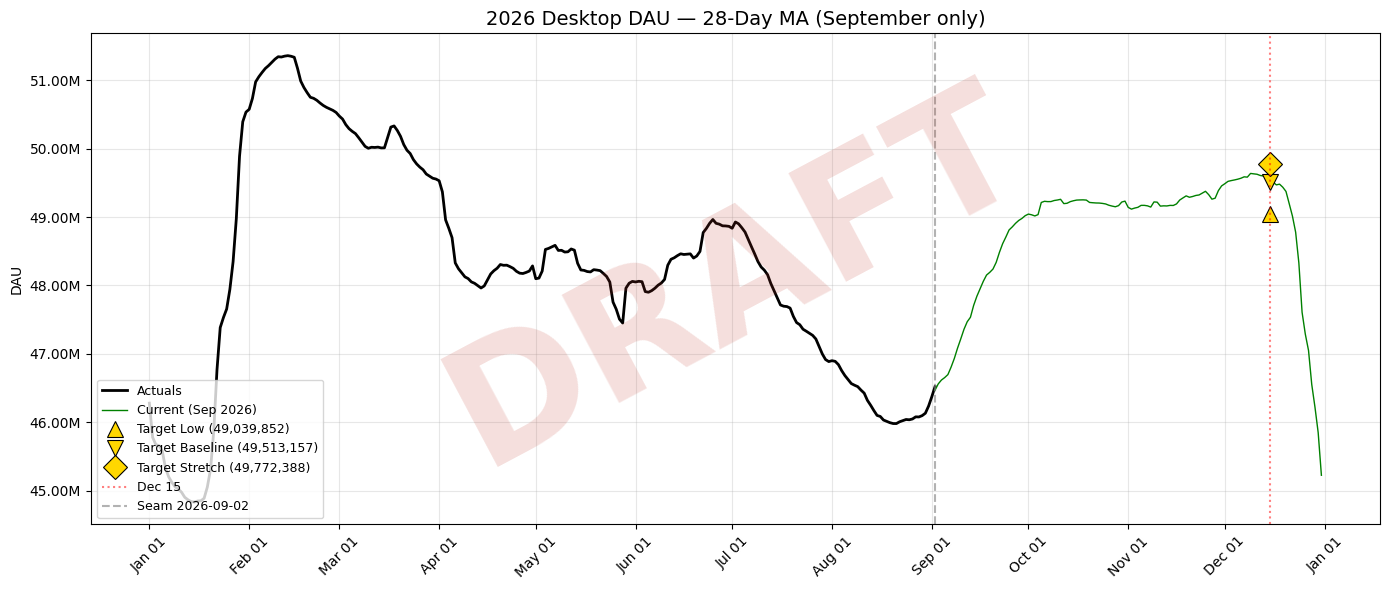

saved: data-official/2026-09/plots/desktop_current_only_with_2025.png


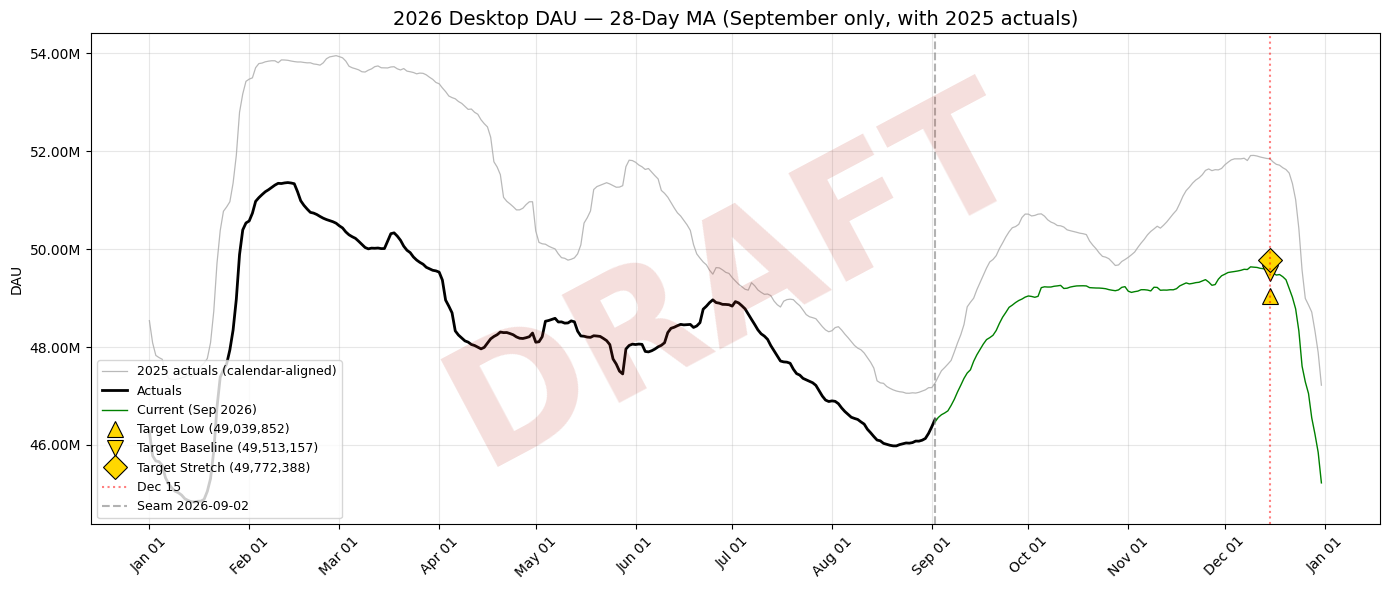

saved: data-official/2026-09/plots/mobile_current_vs_august.png


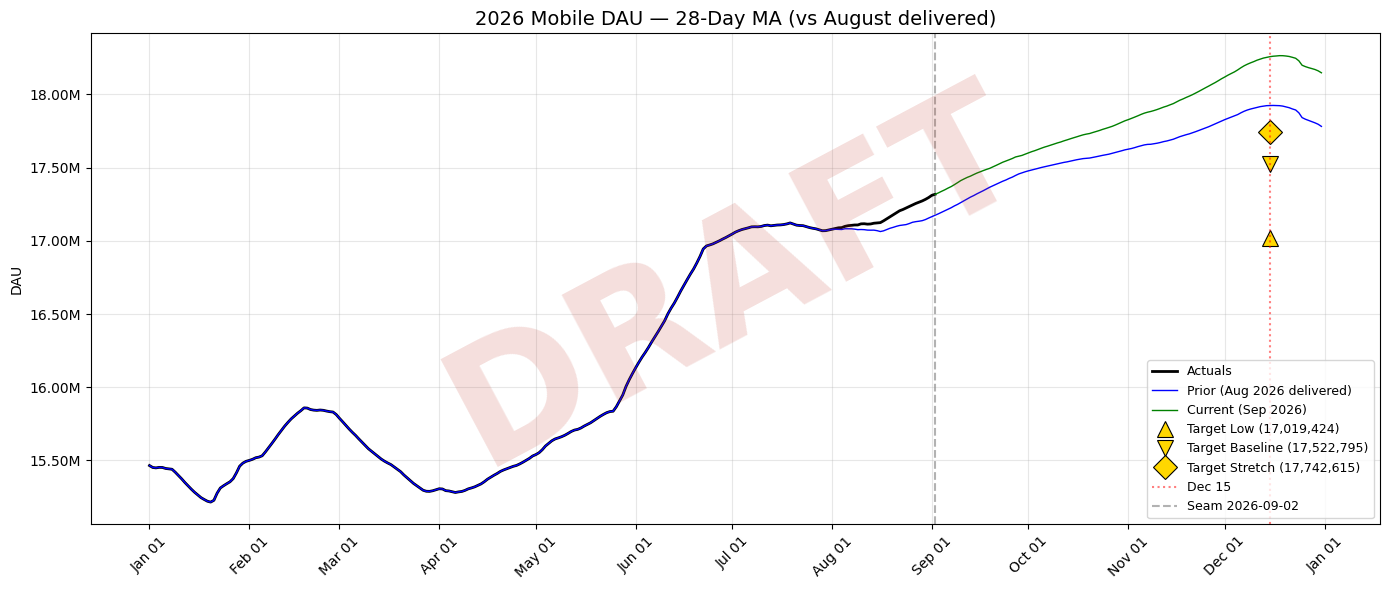

saved: data-official/2026-09/plots/mobile_current_vs_august_with_2025.png


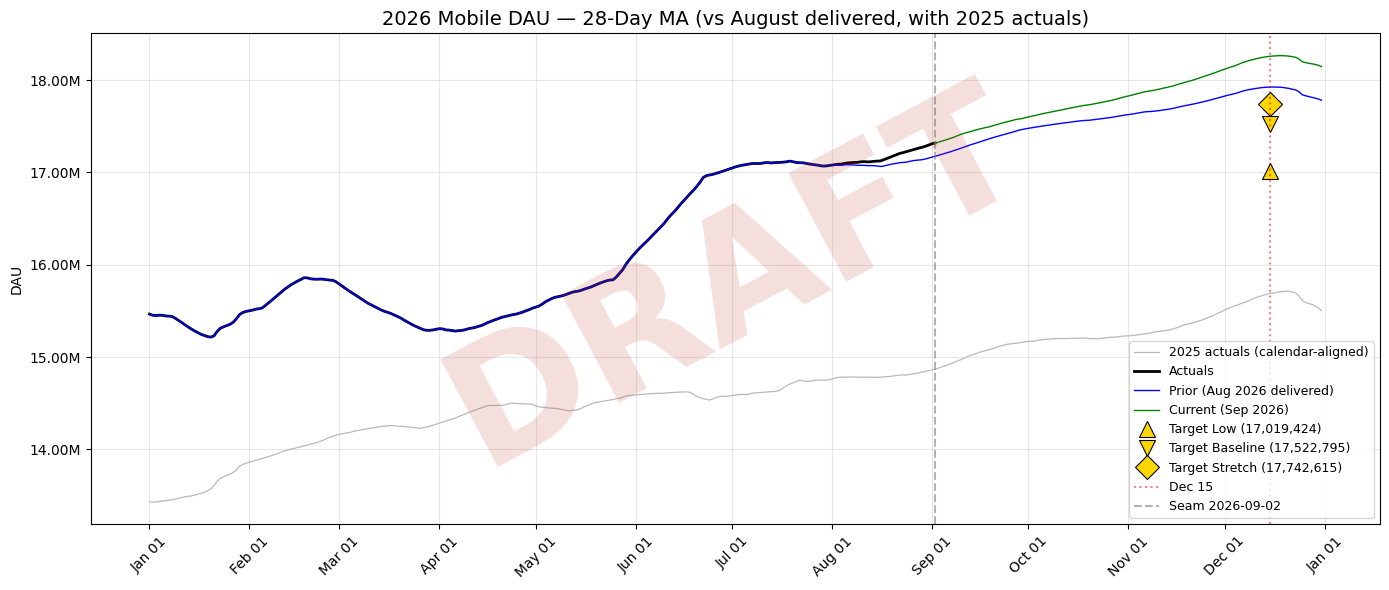

saved: data-official/2026-09/plots/mobile_current_only.png


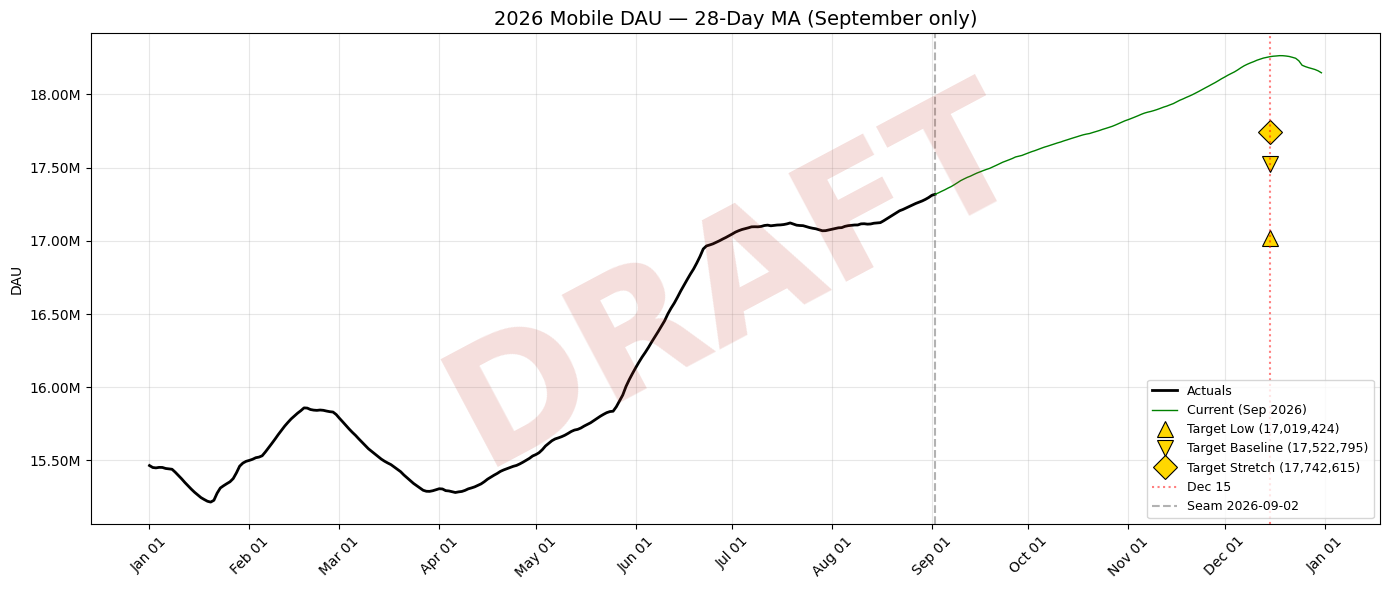

saved: data-official/2026-09/plots/mobile_current_only_with_2025.png


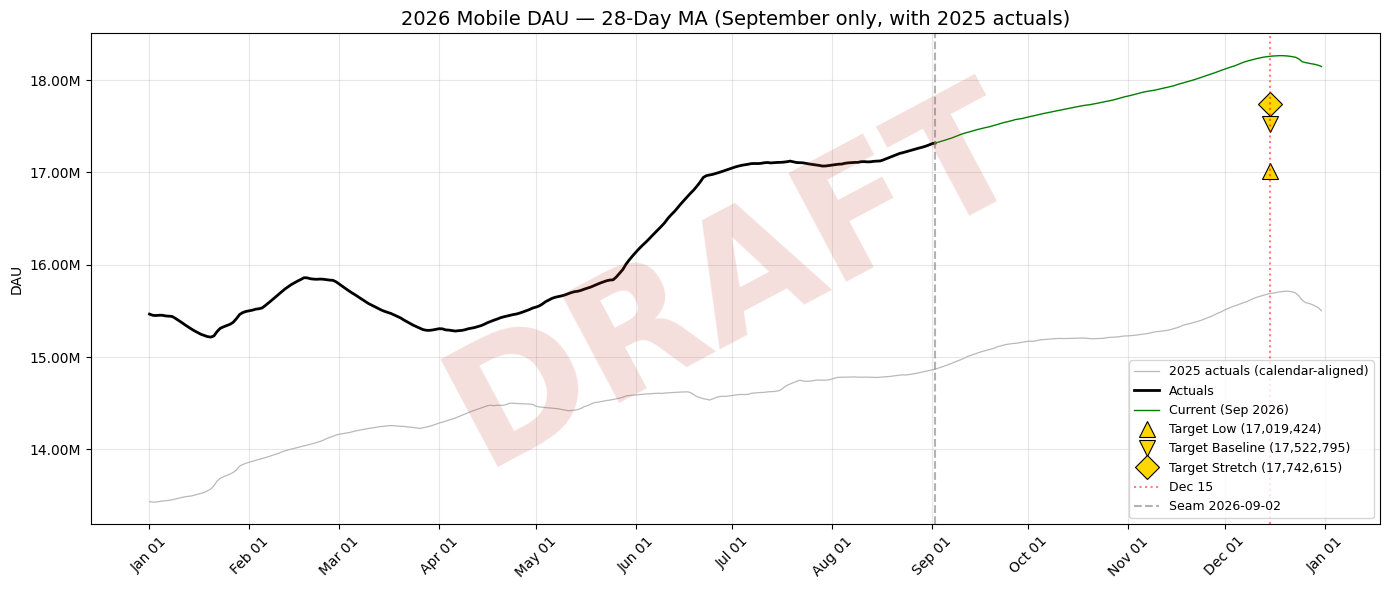

In [8]:
# [plot-headline]
# Eight PNGs: {desktop, mobile} x {vs prior, current only} x {without, with 2025}. Targets on every chart.
PLATFORMS = {
    "desktop": dict(actual=desktop_actual_ma, prior=prev_desktop_ma, current=desktop_ma, ref=desktop_ref_2025,
                    seam=FORECAST_START, legend_loc="lower left"),
    "mobile": dict(actual=mobile_actual_ma, prior=prev_mobile_ma, current=mobile_ma, ref=mobile_ref_2025,
                   seam=MOBILE_FORECAST_START, legend_loc="lower right"),
}


def render_headline_plot(platform, *, show_prior, show_2025):
    p = PLATFORMS[platform]
    fig, ax = plt.subplots(figsize=(14, 6))
    if show_2025:   # true 2025 levels, faint and behind everything
        ax.plot(p["ref"], label=f"{REFERENCE_YEAR} actuals (calendar-aligned)", color="grey", linewidth=0.9, alpha=0.55, zorder=1)
    ax.plot(clip_display(p["actual"]), label="Actuals", color="black", linewidth=2)
    if show_prior:
        ax.plot(clip_display(p["prior"]), label="Prior (Aug 2026 delivered)", color="blue", linewidth=1)
    ax.plot(clip_forecast_only(p["current"], p["seam"]), label="Current (Sep 2026)", color="green", linewidth=1)
    draw_targets(ax, platform)
    ax.axvline(MEASUREMENT_DATE, color="red", linestyle=":", alpha=0.5, label="Dec 15")
    ax.axvline(p["seam"], color="grey", linestyle="--", alpha=0.6, label=f"Seam {p['seam'].date()}")
    variant = ("vs August delivered" if show_prior else "September only") + (", with 2025 actuals" if show_2025 else "")
    style_time_axis(ax, title=f"2026 {platform.title()} DAU — 28-Day MA ({variant})", legend_loc=p["legend_loc"])
    save_and_show(fig, f"{platform}_{'current_vs_august' if show_prior else 'current_only'}{'_with_2025' if show_2025 else ''}.png")


for _platform in PLATFORMS:
    for _show_prior in (True, False):
        for _show_2025 in (False, True):
            render_headline_plot(_platform, show_prior=_show_prior, show_2025=_show_2025)


In [9]:
# [desktop-dec15]
_last_actual = desktop_actual_ma.dropna()
print(f"latest desktop actual 28d-MA: {_last_actual.iloc[-1]:,.0f} on {_last_actual.index[-1].date()}\n")
desktop_series = {
    "Prior (Aug 2026 delivered)": prev_desktop_ma,
    "Current (Sep 2026)": desktop_ma,
}
dec15_table("DESKTOP — Dec 15, 2026, 28-day MA, display layer applied", desktop_series, "desktop")

print(f"\n{'Trough (seam..' + str(TROUGH_WINDOW_END.date()) + ')':<30s} {'min':>16s} {'date':>12s}")
for name, s in [("Prior (Aug 2026 delivered)", prev_desktop_ma), ("Current (Sep 2026)", desktop_ma)]:
    w = s.loc[FORECAST_START:TROUGH_WINDOW_END].dropna()
    print(f"{name:<30s} {w.min():>16,.0f} {str(w.idxmin().date()):>12s}")

prior_recomputed = prev_desktop_ma.get(MEASUREMENT_DATE, np.nan)
drift = prior_recomputed - AUGUST_DELIVERED_DESKTOP_DEC15
print(f"\nPrior reproduces August delivered: {prior_recomputed:,.0f} vs {AUGUST_DELIVERED_DESKTOP_DEC15:,.0f} (drift {drift:+,.0f})")
assert abs(drift) < 1000, "August's delivered desktop Dec-15 does not reproduce; do not quote deltas."

# Attribution ledger (mirrors _index.md). Pin each step once measured by differencing two builds that differ
# in exactly one input; never re-run a historical build. None => closure check skipped, loudly.
DATA_REFRESH_AND_REGATE = None
J_JAPAN_BOT_ADDBACK = None        # expected ~ +67,094
I_INDIA_EXCESS_ADDBACK = None     # expected ~ +41,945
O_MOZILLAONLINE_REFRESH = None    # curve +101,290; realised effect empirical
headwind_step = net_adjustments["desktop"].get(MEASUREMENT_DATE) - prev_net_adjustments["desktop"].get(MEASUREMENT_DATE)
steps = [
    ("+ data refresh + re-gated overlays", DATA_REFRESH_AND_REGATE),
    ("+ `j` japan_bot add-back", J_JAPAN_BOT_ADDBACK),
    ("+ `i` india_excess add-back", I_INDIA_EXCESS_ADDBACK),
    ("+ `o` MozillaOnline curve refresh", O_MOZILLAONLINE_REFRESH),
    (f"+ `h` {prev_net_adjustments['desktop'].get(MEASUREMENT_DATE):,.0f} -> {net_adjustments['desktop'].get(MEASUREMENT_DATE):,.0f}", headwind_step),
]
current = desktop_ma.get(MEASUREMENT_DATE, np.nan)
running = AUGUST_DELIVERED_DESKTOP_DEC15
print(f"\n{'Dec-15 desktop ledger':<44s} {'step':>10s}  {'running':>12s}")
print(f"{'August delivered':<44s} {'':>10s}  {running:>12,.0f}")
if any(step is None for _, step in steps):
    for label, step in steps:
        print(f"{label:<44s} {('pending' if step is None else f'{step:+,.0f}'):>10s}")
    print("*** unpinned steps: closure check skipped ***")
else:
    for label, step in steps:
        running += step
        print(f"{label:<44s} {step:>+10,.0f}  {running:>12,.0f}")
    assert abs(current - running) < 1, f"ledger does not close (residual {current - running:+,.0f})"
print(f"\nNet vs August delivered: {current - AUGUST_DELIVERED_DESKTOP_DEC15:+,.0f} ({(current / AUGUST_DELIVERED_DESKTOP_DEC15 - 1) * 100:+.2f}%)")


latest desktop actual 28d-MA: 46,520,243 on 2026-09-02

DESKTOP — Dec 15, 2026, 28-day MA, display layer applied
Series / target                   Dec 15 28d-MA    Current − row        %
-------------------------------------------------------------------------
Prior (Aug 2026 delivered)           48,703,443         +842,347   +1.73%
Current (Sep 2026)                   49,545,790               +0   +0.00%
Target Low                           49,039,852         +505,938   +1.03%
Target Baseline                      49,513,157          +32,633   +0.07%
Target Stretch                       49,772,388         -226,598   -0.46%

Trough (seam..2026-10-15)                   min         date
Prior (Aug 2026 delivered)           45,559,272   2026-09-02
Current (Sep 2026)                   46,468,193   2026-09-02

Prior reproduces August delivered: 48,703,443 vs 48,703,443 (drift -0)

Dec-15 desktop ledger                              step       running
August delivered                          

saved: data-official/2026-09/plots/desktop_adjustment_ladder.png


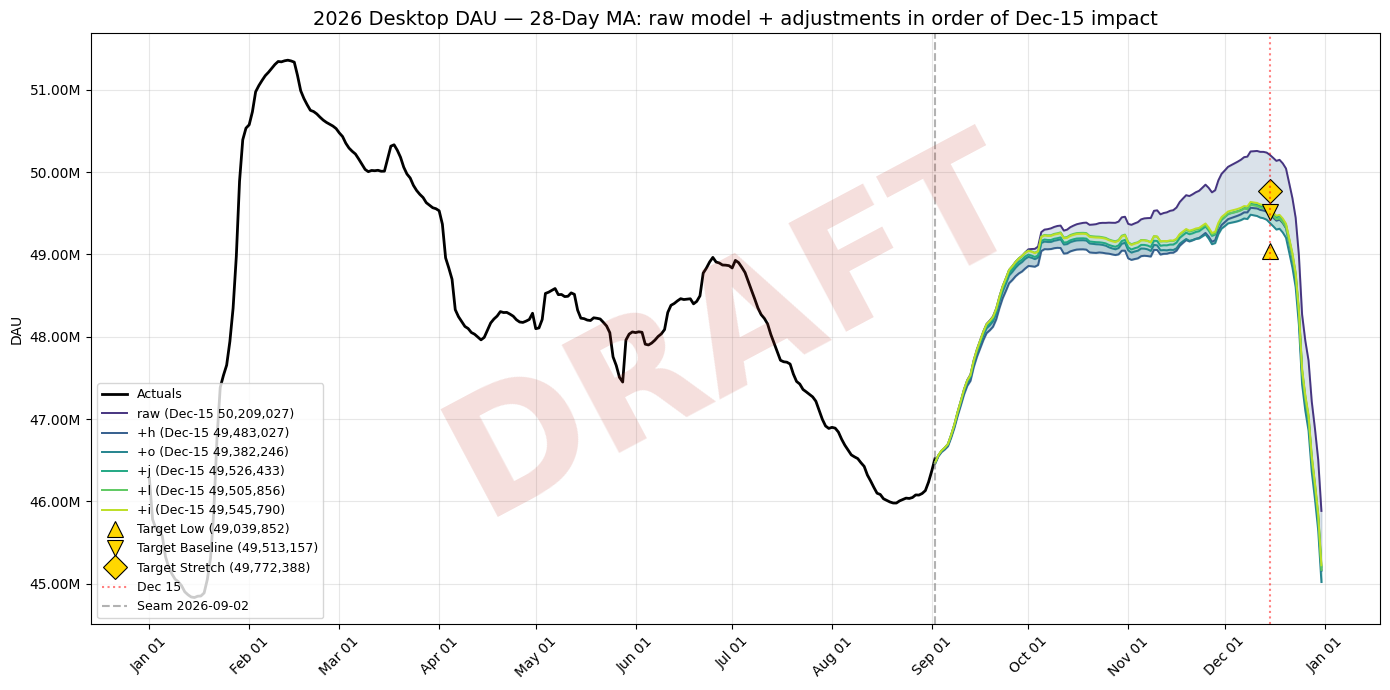

rung      Dec 15 28d-MA         step   built 2026-09-04T22:59:47+00:00
raw          50,209,027             
+h           49,483,027     -726,000
+o           49,382,246     -100,781
+j           49,526,433     +144,187
+l           49,505,856      -20,577
+i           49,545,790      +39,934


In [10]:
# [plot-desktop-ladder]
# Raw model -> each adjustment added in |Dec-15 effect| order -> published. Reads the manifest written by
# scripts/build_adjustment_ladder.py (cached model runs). This cell never runs the model, so the chart
# refreshes only when that script is re-run, and the script asks before forecasting: ladder reruns are a
# human decision, not something to trigger during a broad refresh. Display-layer pieces are rendered from the CURRENT specs; a
# warning prints if their Dec-15 value differs from the one the ordering was computed with.
from mozaic_daily.ladder import cumulative_curves  # noqa: E402

if not LADDER_MANIFEST.exists():
    print(f"no ladder yet. Build it with:\n  python scripts/build_adjustment_ladder.py --cycle {CYCLE} "
          f"--forecast-start-date {FORECAST_START.date()} --raw-cache-dir <desktop raw pull dir> "
          f"--config-from {DESKTOP_FORECAST_PATH}.meta.json")
else:
    manifest = json.loads(LADDER_MANIFEST.read_text())
    assert manifest["forecast_start"] == str(FORECAST_START.date()), "ladder was built at a different seam"
    assert manifest["model_config"] == desktop_meta["model_config"], "ladder config != canonical parquet config"
    overlay_codes = set(manifest["overlay_codes"])

    run_curves = {}
    for run in manifest["runs"].values():
        subset = frozenset(run["overlay_subset"])
        df_run, _ = load_all_level_dau(run["parquet"], "legacy_desktop", '{"os": "ALL"}', "desktop", require_state=sorted(subset))
        run_curves[subset] = display_ma(df_run["target_date"], df_run["dau"], FORECAST_START)

    display_curves, stale = {}, {}
    for spec_path in sorted(glob.glob(f"{ADJUSTMENTS_DIR}/*.json")):
        spec = json.load(open(spec_path))
        code_letter = spec.get("adjustment_code") or Path(spec_path).stem[0]
        if code_letter in manifest["display_effects_dec15"]:
            display_curves[code_letter] = render_adjustment(spec, desktop_ma_raw.index, spec_dir=Path(spec_path).parent)["desktop"]
            now, then = display_curves[code_letter].get(MEASUREMENT_DATE), manifest["display_effects_dec15"][code_letter]
            if abs(now - then) > 0.5:
                stale[code_letter] = (then, now)
    if stale:
        print(f"WARNING: display-layer specs changed since the ladder was ordered {stale}; order may be stale. Re-run the script to re-order.")

    curves = cumulative_curves(manifest["order"], overlay_codes, run_curves, display_curves, FORECAST_START)
    top = list(curves.values())[-1]
    assert abs(top.get(MEASUREMENT_DATE) - desktop_ma.get(MEASUREMENT_DATE)) < 1, "ladder top rung != published desktop Dec-15"

    fig, ax = plt.subplots(figsize=(14, 7))
    ax.plot(clip_display(desktop_actual_ma), label="Actuals", color="black", linewidth=2)
    colors = plt.cm.viridis(np.linspace(0.15, 0.9, len(curves)))
    previous = None
    for (label, s), color in zip(curves.items(), colors):
        shown = clip_forecast_only(s, FORECAST_START)
        ax.plot(shown, color=color, linewidth=1.4, label=f"{label} (Dec-15 {shown.get(MEASUREMENT_DATE):,.0f})")
        if previous is not None:
            ax.fill_between(shown.index, previous.reindex(shown.index), shown, color=color, alpha=0.18)
        previous = shown
    draw_targets(ax, "desktop")
    ax.axvline(MEASUREMENT_DATE, color="red", linestyle=":", alpha=0.5, label="Dec 15")
    ax.axvline(FORECAST_START, color="grey", linestyle="--", alpha=0.6, label=f"Seam {FORECAST_START.date()}")
    style_time_axis(ax, title="2026 Desktop DAU — 28-Day MA: raw model + adjustments in order of Dec-15 impact", legend_loc="lower left")
    save_and_show(fig, "desktop_adjustment_ladder.png")

    print(f"{'rung':<6s} {'Dec 15 28d-MA':>16s} {'step':>12s}   built {manifest['built_at']}")
    previous_value = None
    for label, s in curves.items():
        v = s.get(MEASUREMENT_DATE)
        print(f"{label:<6s} {v:>16,.0f} {('' if previous_value is None else f'{v - previous_value:+,.0f}'):>12s}")
        previous_value = v


saved: data-official/2026-09/plots/mobile_ex_iran_current_vs_august.png


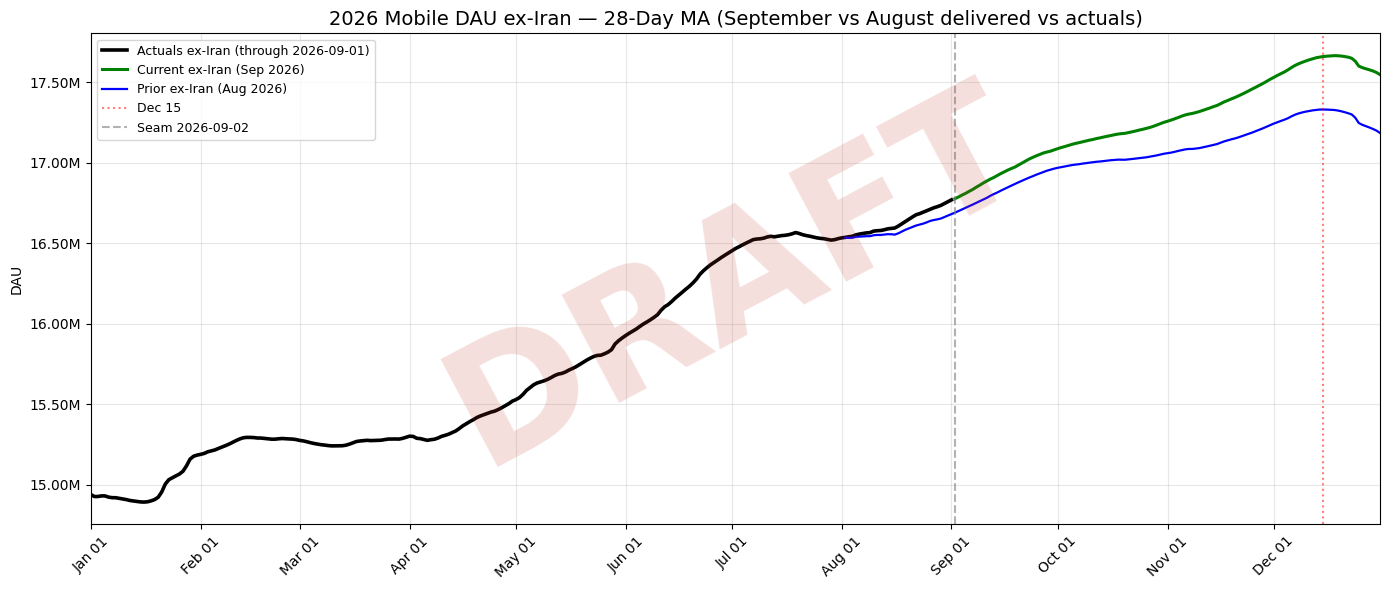

Dec-15 ex-Iran 28d MA        current          prior        delta
                 17,658,755     17,329,833     +328,923


In [11]:
# [plot-mobile-ex-iran]
# ALL-MOBILE minus IR (28d MA): current vs prior vs actuals, each from its own parquet with its own seam and
# display layer. Kept because the Iran view is still occasionally asked for.


def ex_iran_ma(parquet_path, seam, require_state, adjustments):
    """(forecast_ma, actual_ma) for World-minus-Iran mobile DAU."""
    df, _ = load_forecast(parquet_path, require_state=require_state)
    df["target_date"] = pd.to_datetime(df["target_date"])

    def series(country, data_type=None):
        mask = ((df.data_source == "glean_mobile") & (df.country == country) & (df.app_name == "ALL MOBILE") & (df.segment == "{}"))
        rows = df.loc[mask]
        if data_type is not None:
            rows = rows[rows.data_type == data_type]
        return rows.set_index("target_date").sort_index()["dau"]

    ex_ir = series("ALL").subtract(series("IR"), fill_value=0.0)
    forecast_ma = apply_net_adjustment_to_series(display_ma(ex_ir.index.to_series(), ex_ir, seam), adjustments, "mobile", seam)
    act = series("ALL", "training").subtract(series("IR", "training"), fill_value=0.0)
    return forecast_ma, daily_to_28ma(act.index.to_series(), act)


cur_exir_ma, act_exir_ma = ex_iran_ma(MOBILE_FORECAST_PATH, MOBILE_FORECAST_START, MOBILE_REQUIRED_STATE, net_adjustments)
prev_exir_ma, _ = ex_iran_ma(PREV_FORECAST_MOBILE_PATH, PREV_FORECAST_START, PREV_MOBILE_REQUIRED_STATE, prev_net_adjustments)
LAST_ACTUAL_DAY = MOBILE_FORECAST_START - pd.Timedelta(days=1)

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(act_exir_ma.loc[DISPLAY_START:LAST_ACTUAL_DAY], color="black", linewidth=2.6, label=f"Actuals ex-Iran (through {LAST_ACTUAL_DAY.date()})")
ax.plot(cur_exir_ma.loc[MOBILE_FORECAST_START:DISPLAY_END], color="green", linewidth=2.2, label="Current ex-Iran (Sep 2026)")
ax.plot(prev_exir_ma.loc[PREV_FORECAST_START:DISPLAY_END], color="blue", linewidth=1.6, label="Prior ex-Iran (Aug 2026)")
ax.axvline(MEASUREMENT_DATE, color="red", linestyle=":", alpha=0.5, label="Dec 15")
ax.axvline(MOBILE_FORECAST_START, color="grey", linestyle="--", alpha=0.6, label=f"Seam {MOBILE_FORECAST_START.date()}")
ax.set_xlim(DISPLAY_START, DISPLAY_END)
style_time_axis(ax, title="2026 Mobile DAU ex-Iran — 28-Day MA (September vs August delivered vs actuals)", legend_loc="upper left")
save_and_show(fig, "mobile_ex_iran_current_vs_august.png")

print(f"{'Dec-15 ex-Iran 28d MA':<12s} {'current':>14s} {'prior':>14s} {'delta':>12s}")
_c, _p = cur_exir_ma.get(MEASUREMENT_DATE, np.nan), prev_exir_ma.get(MEASUREMENT_DATE, np.nan)
print(f"{'':<12s} {_c:>14,.0f} {_p:>14,.0f} {_c - _p:>+12,.0f}")


In [12]:
# [mobile-dec15]
mobile_series = {
    "Prior (Aug 2026 delivered)": prev_mobile_ma,
    "Current (Sep 2026)": mobile_ma,
}
dec15_table("MOBILE — Dec 15, 2026, 28-day MA, display layer applied", mobile_series, "mobile")

prior_recomputed = prev_mobile_ma.get(MEASUREMENT_DATE, np.nan)
drift = prior_recomputed - AUGUST_DELIVERED_MOBILE_DEC15
print(f"\nPrior reproduces August delivered: {prior_recomputed:,.0f} vs {AUGUST_DELIVERED_MOBILE_DEC15:,.0f} (drift {drift:+,.0f})")
assert abs(drift) < 1000, "August's delivered mobile Dec-15 does not reproduce; do not quote deltas."

# How the published mobile number is built: parquet (`p` applied) + every display-layer spec, listed separately.
current = mobile_ma.get(MEASUREMENT_DATE, np.nan)
model_base = mobile_ma_raw.get(MEASUREMENT_DATE)
print(f"\n{'published mobile Dec-15, built up':<38s} {'':>14s}")
print(f"{'model base (parquet, p applied)':<38s} {model_base:>14,.0f}")
for spec_path in sorted(glob.glob(f"{ADJUSTMENTS_DIR}/*.json")):
    spec = json.load(open(spec_path))
    at_dec15 = render_adjustment(spec, mobile_ma.index, spec_dir=Path(spec_path).parent)["mobile"].get(MEASUREMENT_DATE, 0.0)
    if at_dec15:
        print(f"{'+ ' + os.path.basename(spec_path):<38s} {at_dec15:>+14,.0f}")
print(f"{'= published':<38s} {current:>14,.0f}   (display layer {(current - model_base) / current * 100:+.2f}% of total)")

# Accidental-rebuild guard: pin after the September mobile build is signed off.
PINNED_MOBILE_DEC15 = None
if PINNED_MOBILE_DEC15 is None:
    print("\n*** PINNED_MOBILE_DEC15 unpinned: accidental-drift guard inactive ***")
else:
    assert abs(current - PINNED_MOBILE_DEC15) < 1, f"mobile Dec-15 moved {current - PINNED_MOBILE_DEC15:+,.0f} vs its pin"


MOBILE — Dec 15, 2026, 28-day MA, display layer applied
Series / target                   Dec 15 28d-MA    Current − row        %
-------------------------------------------------------------------------
Prior (Aug 2026 delivered)           17,924,562         +333,448   +1.86%
Current (Sep 2026)                   18,258,010               +0   +0.00%
Target Low                           17,019,424       +1,238,586   +7.28%
Target Baseline                      17,522,795         +735,215   +4.20%
Target Stretch                       17,742,615         +515,395   +2.90%

Prior reproduces August delivered: 17,924,562 vs 17,924,562 (drift -0)

published mobile Dec-15, built up                    
model base (parquet, p applied)            17,986,172
+ tailwind.json                              +299,000
+ tou_mobile_headwind.json                    -27,162
= published                                18,258,010   (display layer +1.49% of total)

*** PINNED_MOBILE_DEC15 unpinned: accidental-dri

saved: data-official/2026-09/plots/mobile_organic_paid_decomposition.png


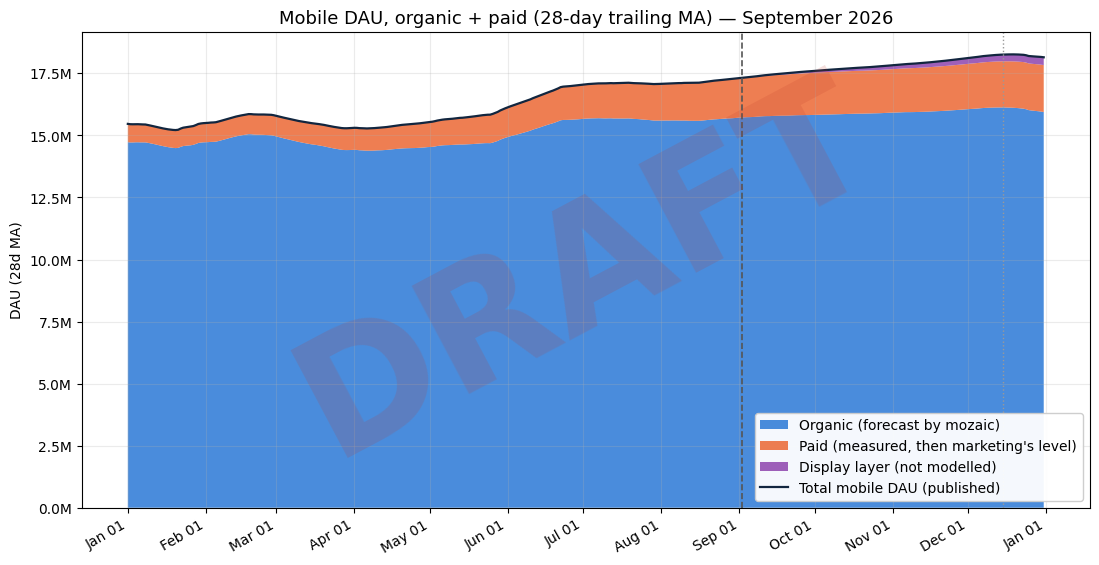

date                 total       organic         paid    display   paid %
2026-01-01      15,465,127    14,726,204      738,922          0     4.8%
2026-09-01      17,311,000    15,719,898    1,591,102          0     9.2%
2026-12-15      18,258,010    16,126,749    1,859,424    271,838    10.2%
paid seam step: -32,372 DAU (-0.19% of total)


In [13]:
# [plot-mobile-organic-paid]
# Mobile DAU as organic (mozaic forecast) + paid (measured before the seam, marketing's level after) +
# display layer, stacked so the bands sum to the published total. The paid seam step is reported, not smoothed.
from mozaic_daily.organic import (  # noqa: E402
    build_share_lookup, load_organic_spec, load_split_frame, marketing_paid_level, split_training_to_organic,
)

ORGANIC_SPEC_DIR = Path(f"{CYCLE_DIR}/organic")
_spec = load_organic_spec(ORGANIC_SPEC_DIR / "organic.json")
_split = load_split_frame(_spec, ORGANIC_SPEC_DIR)
_raw_mobile = pd.read_parquet(Path(MOBILE_FORECAST_PATH).parent / "mozaic_parts.raw.glean.mobile.DAU.parquet")
_raw_mobile["x"] = pd.to_datetime(_raw_mobile["x"])
_lookup = build_share_lookup(
    _split, share_column=_spec["share_column"], training_dates=pd.DatetimeIndex(sorted(_raw_mobile["x"].unique())),
    countries=sorted(set(_raw_mobile["country"].unique()) - set(_spec["scope"]["exclude_countries"])))
_, measured_paid = split_training_to_organic(_raw_mobile, share_lookup=_lookup, exclude_countries=_spec["scope"]["exclude_countries"])
marketing_paid = marketing_paid_level(_spec, ORGANIC_SPEC_DIR, forecast_start=MOBILE_FORECAST_START, forecast_end=pd.Timestamp("2027-12-31"))

# Measured paid before the seam, marketing's level from the seam on. The raw pull can carry the seam day
# itself, so cut the measured leg at the seam or the two overlap on one date.
_measured_daily = measured_paid.groupby(level="submission_date").sum()
paid_daily = pd.concat([_measured_daily[_measured_daily.index < MOBILE_FORECAST_START],
                        marketing_paid[marketing_paid.index >= MOBILE_FORECAST_START]]).sort_index()
assert paid_daily.index.is_unique
paid_ma = paid_daily.rolling(28).mean()
total_ma = mobile_ma.reindex(paid_ma.index).dropna()
paid_ma = paid_ma.reindex(total_ma.index)
display_band = pd.Series(0.0, index=total_ma.index)
for spec_path in sorted(glob.glob(f"{ADJUSTMENTS_DIR}/*.json")):
    display_band += render_adjustment(json.load(open(spec_path)), total_ma.index, spec_dir=Path(spec_path).parent)["mobile"]
display_band[total_ma.index < MOBILE_FORECAST_START] = 0.0
organic_ma = total_ma - paid_ma - display_band

_w = (total_ma.index >= DISPLAY_START) & (total_ma.index <= DISPLAY_END)
fig, ax = plt.subplots(figsize=(13, 7))
ax.stackplot(total_ma.index[_w], organic_ma[_w].to_numpy(), paid_ma[_w].to_numpy(), display_band[_w].to_numpy(),
             labels=["Organic (forecast by mozaic)", "Paid (measured, then marketing's level)", "Display layer (not modelled)"],
             colors=["#2a78d6", "#eb6834", "#8e44ad"], alpha=0.85)
ax.plot(total_ma.index[_w], total_ma[_w], color="#12263f", lw=1.6, label="Total mobile DAU (published)")
ax.axvline(MOBILE_FORECAST_START, color="#555", ls="--", lw=1.2)
ax.axvline(MEASUREMENT_DATE, color="#999", ls=":", lw=1.0)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v / 1e6:.1f}M"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.set_ylim(0, None)
ax.set_title("Mobile DAU, organic + paid (28-day trailing MA) — September 2026", fontsize=13)
ax.set_ylabel("DAU (28d MA)")
ax.legend(loc="lower right", framealpha=0.95)
ax.grid(alpha=0.25)
fig.autofmt_xdate()
save_and_show(fig, "mobile_organic_paid_decomposition.png")

assert (organic_ma + paid_ma + display_band - total_ma).abs().max() < 1e-6, "bands must reconstruct the published total"
LAST_MEASURED_DAY = MOBILE_FORECAST_START - pd.Timedelta(days=1)   # derived from the seam, never hardcoded
print(f"{'date':12}{'total':>14}{'organic':>14}{'paid':>13}{'display':>11}{'paid %':>9}")
for _d in [DISPLAY_START, LAST_MEASURED_DAY, MEASUREMENT_DATE]:
    _t, _p, _x = total_ma.loc[_d], paid_ma.loc[_d], display_band.loc[_d]
    print(f"{str(_d.date()):12}{_t:>14,.0f}{_t - _p - _x:>14,.0f}{_p:>13,.0f}{_x:>11,.0f}{_p / _t * 100:>8.1f}%")
_seam_step = marketing_paid.loc[MOBILE_FORECAST_START] - measured_paid.loc[LAST_MEASURED_DAY].sum()
print(f"paid seam step: {_seam_step:+,.0f} DAU ({_seam_step / total_ma.loc[LAST_MEASURED_DAY] * 100:+.2f}% of total)")


In [14]:
# [dec15-summary]
rows = []
for label, cur, pri in [("Desktop", desktop_ma, prev_desktop_ma), ("Mobile", mobile_ma, prev_mobile_ma)]:
    rows.append((label, cur.get(MEASUREMENT_DATE, np.nan), pri.get(MEASUREMENT_DATE, np.nan)))
rows.append(("ALL", sum(r[1] for r in rows), sum(r[2] for r in rows)))   # disjoint populations: plain sum

print("Dec 15, 2026 — 28-day MA, display layer applied")
header = f"{'Series':<8}  {'Sep current':>16}  {'Aug delivered':>16}  {'Delta':>12}  {'Delta %':>9}"
print(header)
print("-" * len(header))
for label, cur, pri in rows:
    print(f"{label:<8}  {cur:>16,.0f}  {pri:>16,.0f}  {cur - pri:>+12,.0f}  {(cur / pri - 1) * 100:>+8.2f}%")

print("\nDec 15, 2026 — current vs targets")
header = f"{'Series':<8}  {'Sep current':>16}  " + "  ".join(f"{'vs ' + k:>14}" for k in ("Low", "Baseline", "Stretch"))
print(header)
print("-" * len(header))
for label, cur, _ in rows:
    tgt = TARGETS[label.lower() if label != "ALL" else "ALL"]
    print(f"{label:<8}  {cur:>16,.0f}  " + "  ".join(f"{cur - tgt[k]:>+14,.0f}" for k in ("Low", "Baseline", "Stretch")))

print(f"\nTrough (seam..{TROUGH_WINDOW_END.date()}), 28d MA")
for label, s in [("Desktop", desktop_ma), ("Mobile", mobile_ma)]:
    w = s.loc[FORECAST_START:TROUGH_WINDOW_END].dropna()
    print(f"  {label:<8s} {w.min():>16,.0f} on {w.idxmin().date()}")


Dec 15, 2026 — 28-day MA, display layer applied
Series         Sep current     Aug delivered         Delta    Delta %
---------------------------------------------------------------------
Desktop         49,545,790        48,703,443      +842,347     +1.73%
Mobile          18,258,010        17,924,562      +333,448     +1.86%
ALL             67,803,800        66,628,005    +1,175,795     +1.76%

Dec 15, 2026 — current vs targets
Series         Sep current          vs Low     vs Baseline      vs Stretch
--------------------------------------------------------------------------
Desktop         49,545,790        +505,938         +32,633        -226,598
Mobile          18,258,010      +1,238,586        +735,215        +515,395
ALL             67,803,800      +1,744,524        +767,848        +288,797

Trough (seam..2026-10-15), 28d MA
  Desktop        46,468,193 on 2026-09-02
  Mobile         17,317,681 on 2026-09-02


In [15]:
# [gap-to-flat]
# this year's Dec-15 28d-MA (forecast, adjusted) minus last year's (actuals). Flat = 0, not a target.
gap_rows = []
for label, current_s, reference in [("Desktop", desktop_ma, desktop_ref_2025), ("Mobile", mobile_ma, mobile_ref_2025)]:
    this_year, last_year = current_s.get(MEASUREMENT_DATE, np.nan), reference.get(MEASUREMENT_DATE, np.nan)
    gap_rows.append((label, last_year, this_year, this_year - last_year))
gap_rows.append(("ALL", *(sum(r[k] for r in gap_rows) for k in (1, 2, 3))))
assert abs(gap_rows[-1][3] - (gap_rows[-1][2] - gap_rows[-1][1])) < 1e-6

print(f"GAP TO FLAT at Dec 15 — 2026 forecast vs {REFERENCE_YEAR} actuals (28-day MA)")
header = f"{'Series':<8}{REFERENCE_YEAR:>15}{'2026':>15}{'gap to flat':>16}{'vs flat':>10}"
print(header)
print("-" * len(header))
for label, last_year, this_year, gap in gap_rows:
    print(f"{label:<8}{last_year:>15,.0f}{this_year:>15,.0f}{gap:>+16,.0f}{gap / last_year * 100:>+9.2f}%")
_mobile_display = net_adjustments["mobile"].get(MEASUREMENT_DATE, 0.0)
print(f"\nmobile display layer at Dec-15 {_mobile_display:+,.0f} (flows 1:1 into ALL); excluding it: "
      f"Mobile {gap_rows[1][3] - _mobile_display:+,.0f}, ALL {gap_rows[2][3] - _mobile_display:+,.0f}")


GAP TO FLAT at Dec 15 — 2026 forecast vs 2025 actuals (28-day MA)
Series             2025           2026     gap to flat   vs flat
----------------------------------------------------------------
Desktop      51,846,238     49,545,790      -2,300,447    -4.44%
Mobile       15,690,719     18,258,010      +2,567,291   +16.36%
ALL          67,536,957     67,803,800        +266,843    +0.40%

mobile display layer at Dec-15 +271,838 (flows 1:1 into ALL); excluding it: Mobile +2,295,453, ALL -4,995


In [16]:
# [csv-export]
# Handoff files. Rounding policy: publish from already-rounded values so all_* == desktop_* + mobile_* exactly
# and delta columns equal the difference of the columns beside them; assertions are exact.
os.makedirs(CSV_DIR, exist_ok=True)
_idx = pd.date_range(DISPLAY_START, DISPLAY_END, freq="D")
CURRENT_COL, PRIOR_COL = "current_september", "prior_august"


def _col(series, forecast_start=None):
    s = series.reindex(_idx)
    if forecast_start is not None:
        s = s.where(s.index >= forecast_start)
    return s.round(0)


frame = pd.DataFrame({"date": _idx.strftime("%Y-%m-%d")})
frame["desktop_actuals"] = _col(desktop_actual_ma).values
frame[f"desktop_{PRIOR_COL}"] = _col(prev_desktop_ma).values
frame[f"desktop_{CURRENT_COL}"] = _col(desktop_ma, FORECAST_START).values
frame["mobile_actuals"] = _col(mobile_actual_ma).values
frame[f"mobile_{PRIOR_COL}"] = _col(prev_mobile_ma).values
frame[f"mobile_{CURRENT_COL}"] = _col(mobile_ma, MOBILE_FORECAST_START).values
for family in ["actuals", PRIOR_COL, CURRENT_COL]:
    frame[f"all_{family}"] = frame[f"desktop_{family}"] + frame[f"mobile_{family}"]
curves_path = f"{CSV_DIR}/september_canonical_curves.csv"
frame.to_csv(curves_path, index=False)
print(f"wrote {curves_path}  ({len(frame)} rows x {len(frame.columns)} cols)")

_curves = frame.assign(date=pd.to_datetime(frame["date"])).set_index("date")
summary_rows = []
for name, prefix in [("Desktop", "desktop"), ("Mobile", "mobile"), ("ALL", "all")]:
    cur, pri = _curves.loc[MEASUREMENT_DATE, f"{prefix}_{CURRENT_COL}"], _curves.loc[MEASUREMENT_DATE, f"{prefix}_{PRIOR_COL}"]
    window = _curves.loc[FORECAST_START:TROUGH_WINDOW_END, f"{prefix}_{CURRENT_COL}"].dropna()
    tgt = TARGETS[name.lower() if name != "ALL" else "ALL"]
    summary_rows.append({
        "series": name, "measurement_date": MEASUREMENT_DATE.strftime("%Y-%m-%d"),
        CURRENT_COL: int(cur), PRIOR_COL: int(pri),
        "delta_vs_august": int(cur - pri), "delta_pct_vs_august": round((cur / pri - 1) * 100, 3),
        "target_low": tgt["Low"], "target_baseline": tgt["Baseline"], "target_stretch": tgt["Stretch"],
        "delta_vs_target_baseline": int(cur - tgt["Baseline"]),
        "summer_trough_min": int(window.min()), "summer_trough_date": window.idxmin().strftime("%Y-%m-%d"),
    })
summary = pd.DataFrame(summary_rows)
summary_path = f"{CSV_DIR}/september_dec15_summary.csv"
summary.to_csv(summary_path, index=False)
print(f"wrote {summary_path}")
print(summary.to_string(index=False))

# Round-trip: re-read what was WRITTEN and check it stands on its own.
_rt = pd.read_csv(curves_path, parse_dates=["date"]).set_index("date")
_rt_summary = pd.read_csv(summary_path).set_index("series")
for name, prefix, expected in [("Desktop", "desktop", desktop_ma.get(MEASUREMENT_DATE)), ("Mobile", "mobile", mobile_ma.get(MEASUREMENT_DATE)),
                               ("ALL", "all", desktop_ma.get(MEASUREMENT_DATE) + mobile_ma.get(MEASUREMENT_DATE))]:
    assert abs(_rt.loc[MEASUREMENT_DATE, f"{prefix}_{CURRENT_COL}"] - round(expected)) <= 1, f"{name} Dec-15 in CSV != reviewed curve"
    assert _rt_summary.loc[name, CURRENT_COL] == _rt.loc[MEASUREMENT_DATE, f"{prefix}_{CURRENT_COL}"], f"{name} Dec-15 disagrees between CSVs"
for family in ["actuals", PRIOR_COL, CURRENT_COL]:
    residual = (_rt[f"all_{family}"] - (_rt[f"desktop_{family}"] + _rt[f"mobile_{family}"])).abs()
    assert residual.max() == 0, f"all_{family} != desktop+mobile on {(residual > 0).sum()} rows"
for name, prefix in [("Desktop", "desktop"), ("Mobile", "mobile"), ("ALL", "all")]:
    row = _rt_summary.loc[name]
    cur, pri = _rt.loc[MEASUREMENT_DATE, f"{prefix}_{CURRENT_COL}"], _rt.loc[MEASUREMENT_DATE, f"{prefix}_{PRIOR_COL}"]
    window = _rt.loc[FORECAST_START:TROUGH_WINDOW_END, f"{prefix}_{CURRENT_COL}"].dropna()
    assert row[PRIOR_COL] == pri and row["delta_vs_august"] == cur - pri, f"{name} summary does not reproduce from curves"
    assert row["delta_vs_target_baseline"] == cur - row["target_baseline"], f"{name} target delta does not reproduce"
    assert row["summer_trough_min"] == window.min() and row["summer_trough_date"] == window.idxmin().strftime("%Y-%m-%d"), f"{name} trough does not reproduce"
assert _rt_summary.loc["ALL", "target_baseline"] == _rt_summary.loc["Desktop", "target_baseline"] + _rt_summary.loc["Mobile", "target_baseline"]
assert _rt[f"desktop_{CURRENT_COL}"].first_valid_index() == FORECAST_START and _rt[f"mobile_{CURRENT_COL}"].first_valid_index() == MOBILE_FORECAST_START
print(f"\nRound-trip OK. Actuals end {_rt['desktop_actuals'].last_valid_index().date()} (desktop) / {_rt['mobile_actuals'].last_valid_index().date()} (mobile)")


wrote data-official/2026-09/csv/september_canonical_curves.csv  (365 rows x 10 cols)
wrote data-official/2026-09/csv/september_dec15_summary.csv
 series measurement_date  current_september  prior_august  delta_vs_august  delta_pct_vs_august  target_low  target_baseline  target_stretch  delta_vs_target_baseline  summer_trough_min summer_trough_date
Desktop       2026-12-15           49545790      48703443           842347                1.730    49039852         49513157        49772388                     32633           46468193         2026-09-02
 Mobile       2026-12-15           18258010      17924562           333448                1.860    17019424         17522795        17742615                    735215           17317681         2026-09-02
    ALL       2026-12-15           67803800      66628005          1175795                1.765    66059276         67035952        67515003                    767848           63785874         2026-09-02

Round-trip OK. Actuals end 2026-09